# CS201L: Artificial Intelligence Laboratory
## Lab 5: Dimensionality Reduction and Distance-Based Classification using PCA and KNN
### Dataset: MNIST Handwritten Digits (5 Classes: 0-4)

 
**Date:** 01-02-2026

---
## Import Required Libraries

In [39]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import fetch_openml

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


---
# Part A: Data Preparation, Standardization, and PCA

## Step 1: Load the MNIST Dataset and Filter for 5 Classes

In [40]:
# Load MNIST dataset
print("Loading MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, parser='auto')
X_full = mnist.data
y_full = mnist.target.astype(int)

# Filter for only digits 0-4 (5 classes)
mask = y_full <= 4
X = X_full[mask]
y = y_full[mask]

# Convert to DataFrame for easier manipulation
df = pd.DataFrame(X)
df['Class'] = y.values

print(f"Dataset Shape: {df.shape}")
print(f"\nClass distribution:")
print(df['Class'].value_counts().sort_index())
print(f"\nFirst 5 rows:")
df.head()

Loading MNIST dataset...
Dataset Shape: (35735, 785)

Class distribution:
Class
0    6903
1    7877
2    6990
3    7141
4    6824
Name: count, dtype: int64

First 5 rows:


,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,Class
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


## Step 2: Separate Features and Target

In [41]:
# Separate features and target
X = df.drop('Class', axis=1).values
y = df['Class'].values

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of classes: {len(np.unique(y))}")

Features shape: (35735, 784)
Target shape: (35735,)
Number of features: 784
Number of samples: 35735
Number of classes: 5


## Step 3: Train-Validation-Test Split (60-20-20)

In [42]:
# First split: 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)

# Second split: split temp into 50-50 to get 20% validation and 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"Training set:   {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set:       {X_test.shape}")
print(f"\nTraining class distribution:\n{pd.Series(y_train).value_counts().sort_index()}")
print(f"\nValidation class distribution:\n{pd.Series(y_val).value_counts().sort_index()}")
print(f"\nTest class distribution:\n{pd.Series(y_test).value_counts().sort_index()}")

Training set:   (21441, 784)
Validation set: (7147, 784)
Test set:       (7147, 784)

Training class distribution:
0    4142
1    4726
2    4194
3    4285
4    4094
Name: count, dtype: int64

Validation class distribution:
0    1380
1    1576
2    1398
3    1428
4    1365
Name: count, dtype: int64

Test class distribution:
0    1381
1    1575
2    1398
3    1428
4    1365
Name: count, dtype: int64


## Step 4: Save Original Splits

In [43]:
# Create DataFrames with class labels
train_df = pd.DataFrame(X_train)
train_df['Class'] = y_train

val_df = pd.DataFrame(X_val)
val_df['Class'] = y_val

test_df = pd.DataFrame(X_test)
test_df['Class'] = y_test

# Save to CSV
train_df.to_csv('MNIST_Train.csv', index=False)
val_df.to_csv('MNIST_Validation.csv', index=False)
test_df.to_csv('MNIST_Test.csv', index=False)

print("Saved:")
print("  → MNIST_Train.csv")
print("  → MNIST_Validation.csv")
print("  → MNIST_Test.csv")

Saved:
  → MNIST_Train.csv
  → MNIST_Validation.csv
  → MNIST_Test.csv


## Step 5: Standardization

In [44]:
# Fit scaler on training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Use training statistics to transform validation and test
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Scaled training set shape: {X_train_scaled.shape}")
print(f"\nTraining data statistics BEFORE scaling:")
print(f"  Mean: {X_train.mean():.4f}")
print(f"  Std:  {X_train.std():.4f}")
print(f"\nTraining data statistics AFTER scaling:")
print(f"  Mean: {X_train_scaled.mean():.6f}")
print(f"  Std:  {X_train_scaled.std():.4f}")

Scaled training set shape: (21441, 784)

Training data statistics BEFORE scaling:
  Mean: 33.4282
  Std:  78.8917

Training data statistics AFTER scaling:
  Mean: -0.000000
  Std:  0.9189


## Step 6: Save Scaled Datasets

In [45]:
# Create DataFrames with scaled data and class labels
train_scaled_df = pd.DataFrame(X_train_scaled)
train_scaled_df['Class'] = y_train

val_scaled_df = pd.DataFrame(X_val_scaled)
val_scaled_df['Class'] = y_val

test_scaled_df = pd.DataFrame(X_test_scaled)
test_scaled_df['Class'] = y_test

# Save to CSV
train_scaled_df.to_csv('MNIST_Scaled_Train.csv', index=False)
val_scaled_df.to_csv('MNIST_Scaled_Validation.csv', index=False)
test_scaled_df.to_csv('MNIST_Scaled_Test.csv', index=False)

print("Saved:")
print("  → MNIST_Scaled_Train.csv")
print("  → MNIST_Scaled_Validation.csv")
print("  → MNIST_Scaled_Test.csv")

Saved:
  → MNIST_Scaled_Train.csv
  → MNIST_Scaled_Validation.csv
  → MNIST_Scaled_Test.csv


## Step 7: PCA with All Components

In [46]:
# PCA with all components on ORIGINAL (non-scaled) training data
pca_all = PCA(n_components=None)
X_train_pca_all = pca_all.fit_transform(X_train)

# Transform validation and test using same PCA
X_val_pca_all = pca_all.transform(X_val)
X_test_pca_all = pca_all.transform(X_test)

print(f"PCA All Components:")
print(f"  Training shape:   {X_train_pca_all.shape}")
print(f"  Validation shape: {X_val_pca_all.shape}")
print(f"  Test shape:       {X_test_pca_all.shape}")
print(f"\n  Total variance explained: {pca_all.explained_variance_ratio_.sum():.4f}")
print(f"  Number of components: {pca_all.n_components_}")

PCA All Components:
  Training shape:   (21441, 784)
  Validation shape: (7147, 784)
  Test shape:       (7147, 784)

  Total variance explained: 1.0000
  Number of components: 784


## Step 8: Save PCA All Components Datasets

In [47]:
# Create DataFrames with PCA-transformed data
train_pca_all_df = pd.DataFrame(X_train_pca_all)
train_pca_all_df['Class'] = y_train

val_pca_all_df = pd.DataFrame(X_val_pca_all)
val_pca_all_df['Class'] = y_val

test_pca_all_df = pd.DataFrame(X_test_pca_all)
test_pca_all_df['Class'] = y_test

# Save to CSV
train_pca_all_df.to_csv('MNIST_PCA_All_Train.csv', index=False)
val_pca_all_df.to_csv('MNIST_PCA_All_Validation.csv', index=False)
test_pca_all_df.to_csv('MNIST_PCA_All_Test.csv', index=False)

print("Saved:")
print("  → MNIST_PCA_All_Train.csv")
print("  → MNIST_PCA_All_Validation.csv")
print("  → MNIST_PCA_All_Test.csv")

Saved:
  → MNIST_PCA_All_Train.csv
  → MNIST_PCA_All_Validation.csv
  → MNIST_PCA_All_Test.csv


## Step 9: PCA with 95% Variance

In [48]:
# PCA retaining 95% variance on ORIGINAL (non-scaled) training data
pca_95 = PCA(n_components=0.95)
X_train_pca_95 = pca_95.fit_transform(X_train)

# Transform validation and test using same PCA
X_val_pca_95 = pca_95.transform(X_val)
X_test_pca_95 = pca_95.transform(X_test)

print(f"PCA 95% Variance:")
print(f"  Training shape:   {X_train_pca_95.shape}")
print(f"  Validation shape: {X_val_pca_95.shape}")
print(f"  Test shape:       {X_test_pca_95.shape}")
print(f"\n  Components retained: {pca_95.n_components_}")
print(f"  Original features:   {X_train.shape[1]}")
print(f"  Reduction:           {(1 - pca_95.n_components_/X_train.shape[1])*100:.1f}%")
print(f"  Variance explained:  {pca_95.explained_variance_ratio_.sum():.4f}")

PCA 95% Variance:
  Training shape:   (21441, 139)
  Validation shape: (7147, 139)
  Test shape:       (7147, 139)

  Components retained: 139
  Original features:   784
  Reduction:           82.3%
  Variance explained:  0.9503


## Step 10: Plot Cumulative Explained Variance

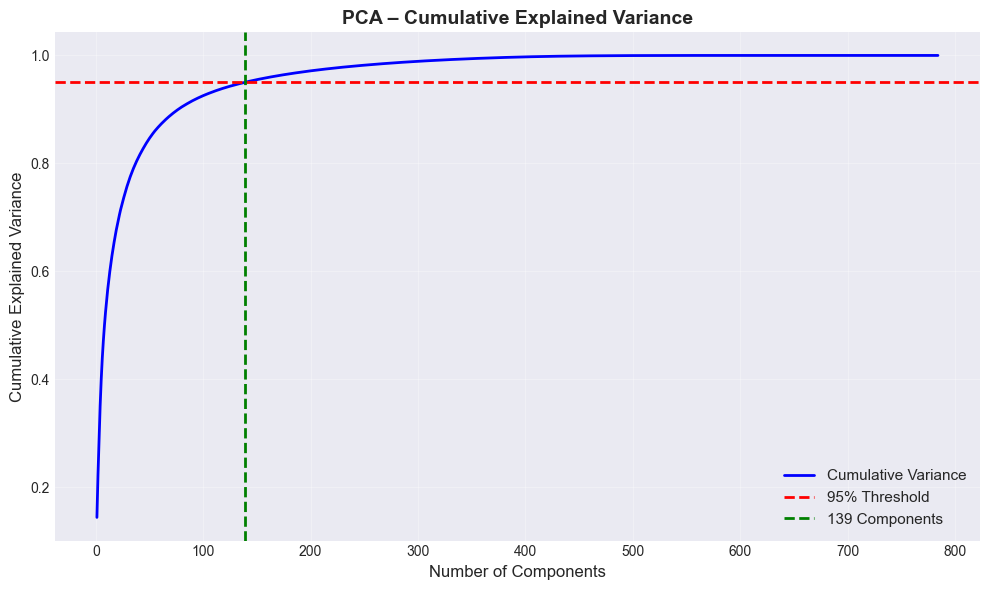


Components needed for 95% variance: 139
Actual components used by PCA(0.95): 139


In [49]:
# Calculate cumulative variance
cumulative_variance = np.cumsum(pca_all.explained_variance_ratio_)

# Find number of components for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 
         'b-', linewidth=2, label='Cumulative Variance')
plt.axhline(y=0.95, color='r', linestyle='--', linewidth=2, label='95% Threshold')
plt.axvline(x=n_components_95, color='g', linestyle='--', linewidth=2, 
            label=f'{n_components_95} Components')

plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance', fontsize=12)
plt.title('PCA – Cumulative Explained Variance', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('cumulative_variance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nComponents needed for 95% variance: {n_components_95}")
print(f"Actual components used by PCA(0.95): {pca_95.n_components_}")

## Step 11: Save PCA 95% Datasets

In [50]:
# Create DataFrames with PCA 95% transformed data
train_pca_95_df = pd.DataFrame(X_train_pca_95)
train_pca_95_df['Class'] = y_train

val_pca_95_df = pd.DataFrame(X_val_pca_95)
val_pca_95_df['Class'] = y_val

test_pca_95_df = pd.DataFrame(X_test_pca_95)
test_pca_95_df['Class'] = y_test

# Save to CSV
train_pca_95_df.to_csv('MNIST_PCA95_Train.csv', index=False)
val_pca_95_df.to_csv('MNIST_PCA95_Validation.csv', index=False)
test_pca_95_df.to_csv('MNIST_PCA95_Test.csv', index=False)

print("Saved:")
print("  → MNIST_PCA95_Train.csv")
print("  → MNIST_PCA95_Validation.csv")
print("  → MNIST_PCA95_Test.csv")

Saved:
  → MNIST_PCA95_Train.csv
  → MNIST_PCA95_Validation.csv
  → MNIST_PCA95_Test.csv


## Summary of Part A

In [51]:
print("=" * 70)
print("  PART A SUMMARY – DATA PREPARATION COMPLETE")
print("=" * 70)
print(f"\n1. Dataset: MNIST Handwritten Digits (5 classes: 0-4)")
print(f"   Total samples:     {len(y)}")
print(f"   Original features: {X.shape[1]}")
print(f"\n2. Train-Validation-Test Split (60-20-20):")
print(f"   Training:   {len(y_train):5d} samples")
print(f"   Validation: {len(y_val):5d} samples")
print(f"   Test:       {len(y_test):5d} samples")
print(f"\n3. Standardization:")
print(f"   StandardScaler fitted on training data")
print(f"   Applied to train, validation, and test sets")
print(f"\n4. PCA Transformations:")
print(f"   PCA All:     {X_train_pca_all.shape[1]} components (100% variance)")
print(f"   PCA 95%:     {pca_95.n_components_} components ({pca_95.explained_variance_ratio_.sum():.2%} variance)")
print(f"   Reduction:   {(1 - pca_95.n_components_/X_train.shape[1])*100:.1f}%")
print(f"\n5. Files Generated: 12 CSV files")
print(f"   Original:       3 files")
print(f"   Scaled:         3 files")
print(f"   PCA All:        3 files")
print(f"   PCA 95%:        3 files")
print(f"\n6. Plot Generated:")
print(f"   cumulative_variance.png")
print("\n" + "=" * 70)

  PART A SUMMARY – DATA PREPARATION COMPLETE

1. Dataset: MNIST Handwritten Digits (5 classes: 0-4)
   Total samples:     35735
   Original features: 784

2. Train-Validation-Test Split (60-20-20):
   Training:   21441 samples
   Validation:  7147 samples
   Test:        7147 samples

3. Standardization:
   StandardScaler fitted on training data
   Applied to train, validation, and test sets

4. PCA Transformations:
   PCA All:     784 components (100% variance)
   PCA 95%:     139 components (95.03% variance)
   Reduction:   82.3%

5. Files Generated: 12 CSV files
   Original:       3 files
   Scaled:         3 files
   PCA All:        3 files
   PCA 95%:        3 files

6. Plot Generated:
   cumulative_variance.png



---
# Part B: KNN on Original Data

## Step 1: Load Original Data

In [52]:
# Load the original datasets
train_orig = pd.read_csv('MNIST_Train.csv')
val_orig = pd.read_csv('MNIST_Validation.csv')
test_orig = pd.read_csv('MNIST_Test.csv')

# Separate features and target
X_train_orig = train_orig.drop('Class', axis=1).values
y_train_orig = train_orig['Class'].values

X_val_orig = val_orig.drop('Class', axis=1).values
y_val_orig = val_orig['Class'].values

X_test_orig = test_orig.drop('Class', axis=1).values
y_test_orig = test_orig['Class'].values

print("Original Data Loaded:")
print(f"  Training:   {X_train_orig.shape}")
print(f"  Validation: {X_val_orig.shape}")
print(f"  Test:       {X_test_orig.shape}")

Original Data Loaded:
  Training:   (21441, 784)
  Validation: (7147, 784)
  Test:       (7147, 784)


## Step 2: KNN with Different K Values on Validation Data

In [53]:
# Define K values to test
K_VALUES = [1, 5, 7, 9, 11, 13]

# Store validation results for each K
results_orig = []

print("Testing KNN on Original Data (Validation Set)...\n")
print("K   Accuracy   Prec_Micro  Prec_Macro  Rec_Micro   Rec_Macro   F1_Micro    F1_Macro")
print("=" * 90)

for k in K_VALUES:
    # Train KNN
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_orig, y_train_orig)
    
    # Predict on validation set
    y_pred = knn.predict(X_val_orig)
    
    # Calculate metrics
    acc = accuracy_score(y_val_orig, y_pred)
    prec_micro = precision_score(y_val_orig, y_pred, average='micro')
    prec_macro = precision_score(y_val_orig, y_pred, average='macro')
    rec_micro = recall_score(y_val_orig, y_pred, average='micro')
    rec_macro = recall_score(y_val_orig, y_pred, average='macro')
    f1_micro = f1_score(y_val_orig, y_pred, average='micro')
    f1_macro = f1_score(y_val_orig, y_pred, average='macro')
    
    # Store results
    results_orig.append({
        'K': k,
        'Accuracy': acc,
        'Precision_Micro': prec_micro,
        'Precision_Macro': prec_macro,
        'Recall_Micro': rec_micro,
        'Recall_Macro': rec_macro,
        'F1_Micro': f1_micro,
        'F1_Macro': f1_macro
    })
    
    print(f"{k:2d}  {acc:.6f}  {prec_micro:.6f}  {prec_macro:.6f}  {rec_micro:.6f}  "
          f"{rec_macro:.6f}  {f1_micro:.6f}  {f1_macro:.6f}")

# Convert to DataFrame
val_orig_df = pd.DataFrame(results_orig)

# Find best K based on accuracy
best_k_orig = val_orig_df.loc[val_orig_df['Accuracy'].idxmax(), 'K']
best_acc_orig = val_orig_df.loc[val_orig_df['Accuracy'].idxmax(), 'Accuracy']

print("\n" + "=" * 90)
print(f"Best K = {int(best_k_orig)} with Validation Accuracy = {best_acc_orig:.6f}")

Testing KNN on Original Data (Validation Set)...

K   Accuracy   Prec_Micro  Prec_Macro  Rec_Micro   Rec_Macro   F1_Micro    F1_Macro
 1  0.990206  0.990206  0.990391  0.990206  0.990096  0.990206  0.990223
 5  0.989086  0.989086  0.989613  0.989086  0.988930  0.989086  0.989211
 7  0.987547  0.987547  0.988114  0.987547  0.987386  0.987547  0.987676
 9  0.987267  0.987267  0.987977  0.987267  0.987086  0.987267  0.987441
11  0.986008  0.986008  0.986821  0.986008  0.985799  0.986008  0.986203
13  0.985448  0.985448  0.986260  0.985448  0.985243  0.985448  0.985640

Best K = 1 with Validation Accuracy = 0.990206


## Step 3: Plot Accuracy vs K

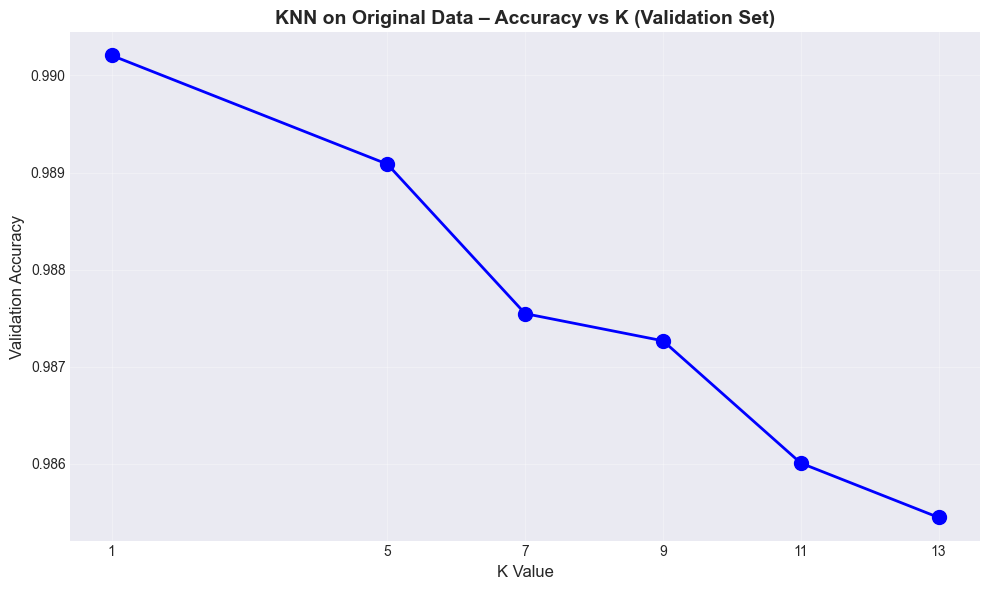

In [54]:
plt.figure(figsize=(10, 6))
plt.plot(val_orig_df['K'], val_orig_df['Accuracy'], 'bo-', linewidth=2, markersize=10)
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.title('KNN on Original Data – Accuracy vs K (Validation Set)', 
          fontsize=14, fontweight='bold')
plt.xticks(K_VALUES)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('acc_vs_k_original.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 4: Evaluate Best K on Test Data

In [55]:
# Train KNN with best K on training data
knn_best_orig = KNeighborsClassifier(n_neighbors=int(best_k_orig))
knn_best_orig.fit(X_train_orig, y_train_orig)

# Predict on test set
y_pred_orig = knn_best_orig.predict(X_test_orig)

# Calculate metrics
acc_test = accuracy_score(y_test_orig, y_pred_orig)
prec_micro_test = precision_score(y_test_orig, y_pred_orig, average='micro')
prec_macro_test = precision_score(y_test_orig, y_pred_orig, average='macro')
rec_micro_test = recall_score(y_test_orig, y_pred_orig, average='micro')
rec_macro_test = recall_score(y_test_orig, y_pred_orig, average='macro')
f1_micro_test = f1_score(y_test_orig, y_pred_orig, average='micro')
f1_macro_test = f1_score(y_test_orig, y_pred_orig, average='macro')

# Confusion matrix
cm_orig = confusion_matrix(y_test_orig, y_pred_orig)

print("=" * 70)
print(f"  PART B: KNN ON ORIGINAL DATA – TEST RESULTS (K={int(best_k_orig)})")
print("=" * 70)
print(f"\nAccuracy:         {acc_test:.6f}")
print(f"Precision (Micro): {prec_micro_test:.6f}")
print(f"Precision (Macro): {prec_macro_test:.6f}")
print(f"Recall (Micro):    {rec_micro_test:.6f}")
print(f"Recall (Macro):    {rec_macro_test:.6f}")
print(f"F1-score (Micro):  {f1_micro_test:.6f}")
print(f"F1-score (Macro):  {f1_macro_test:.6f}")
print(f"\nConfusion Matrix:")
print(cm_orig)

  PART B: KNN ON ORIGINAL DATA – TEST RESULTS (K=1)

Accuracy:         0.991885
Precision (Micro): 0.991885
Precision (Macro): 0.992083
Recall (Micro):    0.991885
Recall (Macro):    0.991746
F1-score (Micro):  0.991885
F1-score (Macro):  0.991896

Confusion Matrix:
[[1376    2    2    0    1]
 [   1 1571    3    0    0]
 [   7   12 1373    4    2]
 [   2    1    5 1417    3]
 [   4    9    0    0 1352]]


## Step 5: Plot Confusion Matrix

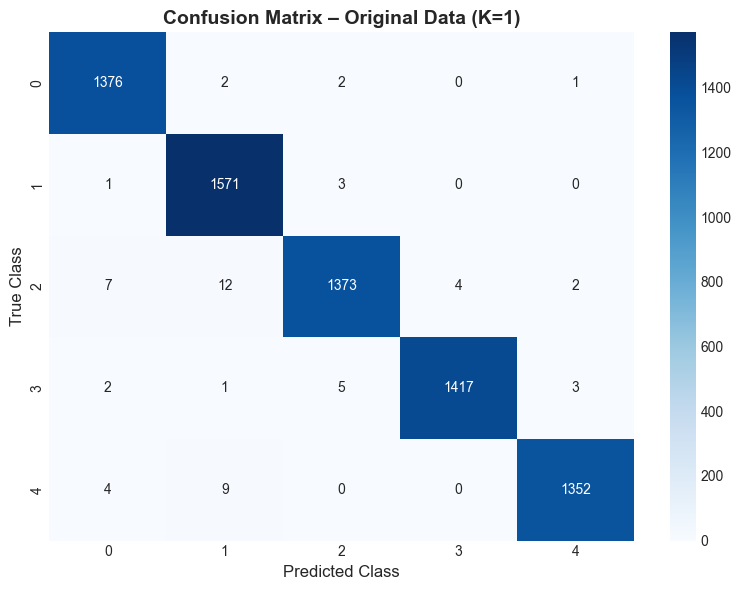

In [56]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(5), yticklabels=range(5))
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.title(f'Confusion Matrix – Original Data (K={int(best_k_orig)})', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cm_original.png', dpi=300, bbox_inches='tight')
plt.show()

---
# Part C: KNN on Standardized Data

## Step 1: Load Standardized Data

In [57]:
# Load the standardized datasets
train_sc = pd.read_csv('MNIST_Scaled_Train.csv')
val_sc = pd.read_csv('MNIST_Scaled_Validation.csv')
test_sc = pd.read_csv('MNIST_Scaled_Test.csv')

# Separate features and target
X_train_sc = train_sc.drop('Class', axis=1).values
y_train_sc = train_sc['Class'].values

X_val_sc = val_sc.drop('Class', axis=1).values
y_val_sc = val_sc['Class'].values

X_test_sc = test_sc.drop('Class', axis=1).values
y_test_sc = test_sc['Class'].values

print("Standardized Data Loaded:")
print(f"  Training:   {X_train_sc.shape}")
print(f"  Validation: {X_val_sc.shape}")
print(f"  Test:       {X_test_sc.shape}")

Standardized Data Loaded:
  Training:   (21441, 784)
  Validation: (7147, 784)
  Test:       (7147, 784)


## Step 2: KNN with Different K Values on Validation Data

In [58]:
# Store validation results for each K
results_sc = []

print("Testing KNN on Standardized Data (Validation Set)...\n")
print("K   Accuracy   Prec_Micro  Prec_Macro  Rec_Micro   Rec_Macro   F1_Micro    F1_Macro")
print("=" * 90)

for k in K_VALUES:
    # Train KNN
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_sc, y_train_sc)
    
    # Predict on validation set
    y_pred = knn.predict(X_val_sc)
    
    # Calculate metrics
    acc = accuracy_score(y_val_sc, y_pred)
    prec_micro = precision_score(y_val_sc, y_pred, average='micro')
    prec_macro = precision_score(y_val_sc, y_pred, average='macro')
    rec_micro = recall_score(y_val_sc, y_pred, average='micro')
    rec_macro = recall_score(y_val_sc, y_pred, average='macro')
    f1_micro = f1_score(y_val_sc, y_pred, average='micro')
    f1_macro = f1_score(y_val_sc, y_pred, average='macro')
    
    # Store results
    results_sc.append({
        'K': k,
        'Accuracy': acc,
        'Precision_Micro': prec_micro,
        'Precision_Macro': prec_macro,
        'Recall_Micro': rec_micro,
        'Recall_Macro': rec_macro,
        'F1_Micro': f1_micro,
        'F1_Macro': f1_macro
    })
    
    print(f"{k:2d}  {acc:.6f}  {prec_micro:.6f}  {prec_macro:.6f}  {rec_micro:.6f}  "
          f"{rec_macro:.6f}  {f1_micro:.6f}  {f1_macro:.6f}")

# Convert to DataFrame
val_sc_df = pd.DataFrame(results_sc)

# Find best K based on accuracy
best_k_sc = val_sc_df.loc[val_sc_df['Accuracy'].idxmax(), 'K']
best_acc_sc = val_sc_df.loc[val_sc_df['Accuracy'].idxmax(), 'Accuracy']

print("\n" + "=" * 90)
print(f"Best K = {int(best_k_sc)} with Validation Accuracy = {best_acc_sc:.6f}")

Testing KNN on Standardized Data (Validation Set)...

K   Accuracy   Prec_Micro  Prec_Macro  Rec_Micro   Rec_Macro   F1_Micro    F1_Macro
 1  0.976634  0.976634  0.976624  0.976634  0.976379  0.976634  0.976463
 5  0.977473  0.977473  0.977586  0.977473  0.977192  0.977473  0.977342
 7  0.974395  0.974395  0.974494  0.974395  0.974078  0.974395  0.974209
 9  0.975094  0.975094  0.975341  0.975094  0.974751  0.975094  0.974965
11  0.973276  0.973276  0.973606  0.973276  0.972882  0.973276  0.973131
13  0.971876  0.971876  0.972309  0.971876  0.971453  0.971876  0.971743

Best K = 5 with Validation Accuracy = 0.977473


## Step 3: Plot Accuracy vs K

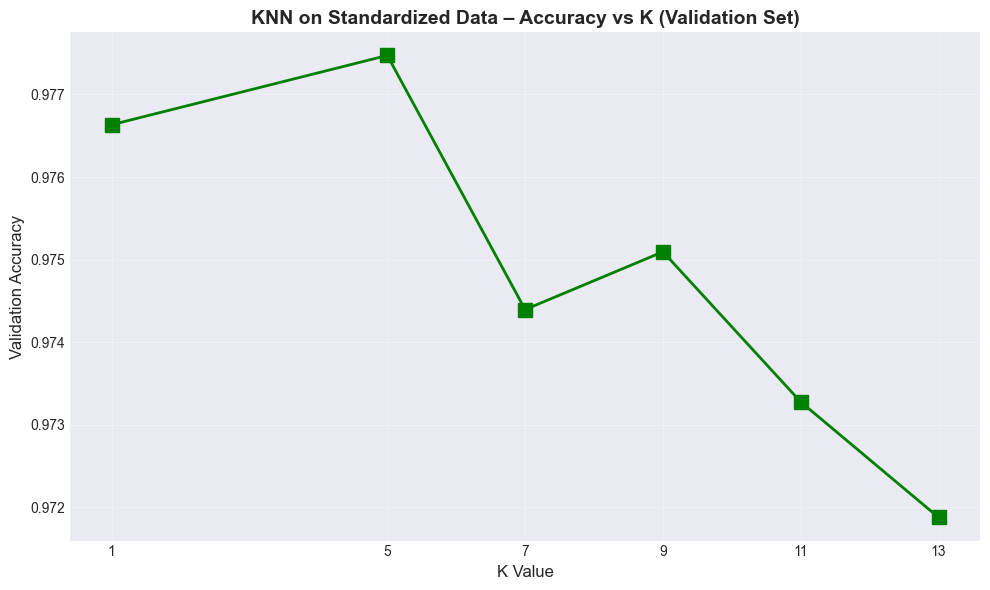

In [59]:
plt.figure(figsize=(10, 6))
plt.plot(val_sc_df['K'], val_sc_df['Accuracy'], 'gs-', linewidth=2, markersize=10)
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.title('KNN on Standardized Data – Accuracy vs K (Validation Set)', 
          fontsize=14, fontweight='bold')
plt.xticks(K_VALUES)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('acc_vs_k_scaled.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 4: Evaluate Best K on Test Data

In [60]:
# Train KNN with best K on training data
knn_best_sc = KNeighborsClassifier(n_neighbors=int(best_k_sc))
knn_best_sc.fit(X_train_sc, y_train_sc)

# Predict on test set
y_pred_sc = knn_best_sc.predict(X_test_sc)

# Calculate metrics
acc_test_sc = accuracy_score(y_test_sc, y_pred_sc)
prec_micro_test_sc = precision_score(y_test_sc, y_pred_sc, average='micro')
prec_macro_test_sc = precision_score(y_test_sc, y_pred_sc, average='macro')
rec_micro_test_sc = recall_score(y_test_sc, y_pred_sc, average='micro')
rec_macro_test_sc = recall_score(y_test_sc, y_pred_sc, average='macro')
f1_micro_test_sc = f1_score(y_test_sc, y_pred_sc, average='micro')
f1_macro_test_sc = f1_score(y_test_sc, y_pred_sc, average='macro')

# Confusion matrix
cm_sc = confusion_matrix(y_test_sc, y_pred_sc)

print("=" * 70)
print(f"  PART C: KNN ON STANDARDIZED DATA – TEST RESULTS (K={int(best_k_sc)})")
print("=" * 70)
print(f"\nAccuracy:         {acc_test_sc:.6f}")
print(f"Precision (Micro): {prec_micro_test_sc:.6f}")
print(f"Precision (Macro): {prec_macro_test_sc:.6f}")
print(f"Recall (Micro):    {rec_micro_test_sc:.6f}")
print(f"Recall (Macro):    {rec_macro_test_sc:.6f}")
print(f"F1-score (Micro):  {f1_micro_test_sc:.6f}")
print(f"F1-score (Macro):  {f1_macro_test_sc:.6f}")
print(f"\nConfusion Matrix:")
print(cm_sc)

# Comparison with Original Data
print(f"\n{'='*70}")
print("  COMPARISON: Original vs Standardized")
print("=" * 70)
print(f"Original Accuracy:     {acc_test:.6f}")
print(f"Standardized Accuracy: {acc_test_sc:.6f}")
print(f"Difference:            {acc_test_sc - acc_test:+.6f}")

  PART C: KNN ON STANDARDIZED DATA – TEST RESULTS (K=5)

Accuracy:         0.975654
Precision (Micro): 0.975654
Precision (Macro): 0.975820
Recall (Micro):    0.975654
Recall (Macro):    0.975400
F1-score (Micro):  0.975654
F1-score (Macro):  0.975570

Confusion Matrix:
[[1367    3    1    5    5]
 [   1 1553    7    2   12]
 [  14   25 1334   16    9]
 [   5    5   14 1394   10]
 [   4   16   12    8 1325]]

  COMPARISON: Original vs Standardized
Original Accuracy:     0.991885
Standardized Accuracy: 0.975654
Difference:            -0.016231


## Step 5: Plot Confusion Matrix

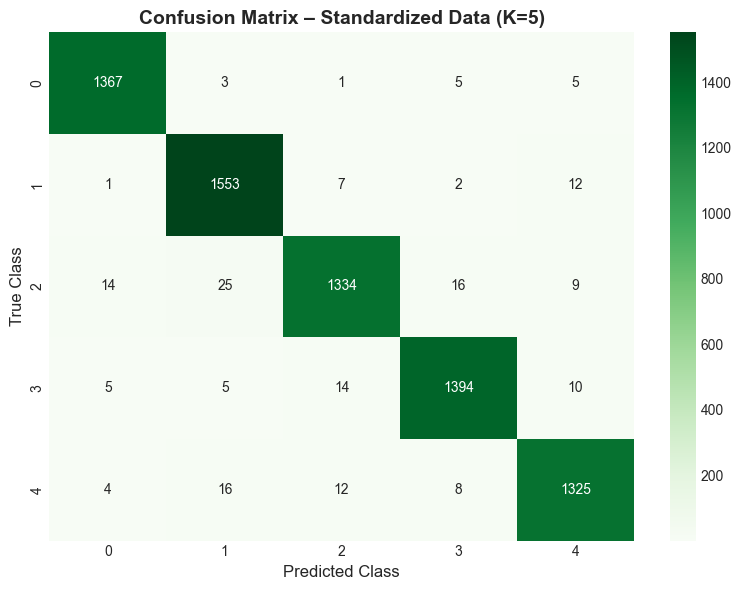

In [61]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_sc, annot=True, fmt='d', cmap='Greens', 
            xticklabels=range(5), yticklabels=range(5))
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.title(f'Confusion Matrix – Standardized Data (K={int(best_k_sc)})', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cm_scaled.png', dpi=300, bbox_inches='tight')
plt.show()

---
# Part D: KNN on PCA (All Components)

## Step 1: Load PCA All Components Data

In [62]:
# Load the PCA all components datasets
train_pa = pd.read_csv('MNIST_PCA_All_Train.csv')
val_pa = pd.read_csv('MNIST_PCA_All_Validation.csv')
test_pa = pd.read_csv('MNIST_PCA_All_Test.csv')

# Separate features and target
X_train_pa = train_pa.drop('Class', axis=1).values
y_train_pa = train_pa['Class'].values

X_val_pa = val_pa.drop('Class', axis=1).values
y_val_pa = val_pa['Class'].values

X_test_pa = test_pa.drop('Class', axis=1).values
y_test_pa = test_pa['Class'].values

print("PCA All Components Data Loaded:")
print(f"  Training:   {X_train_pa.shape}")
print(f"  Validation: {X_val_pa.shape}")
print(f"  Test:       {X_test_pa.shape}")

PCA All Components Data Loaded:
  Training:   (21441, 784)
  Validation: (7147, 784)
  Test:       (7147, 784)


## Step 2: KNN with Different K Values on Validation Data

In [63]:
# Store validation results for each K
results_pa = []

print("Testing KNN on PCA All Components (Validation Set)...\n")
print("K   Accuracy   Prec_Micro  Prec_Macro  Rec_Micro   Rec_Macro   F1_Micro    F1_Macro")
print("=" * 90)

for k in K_VALUES:
    # Train KNN
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_pa, y_train_pa)
    
    # Predict on validation set
    y_pred = knn.predict(X_val_pa)
    
    # Calculate metrics
    acc = accuracy_score(y_val_pa, y_pred)
    prec_micro = precision_score(y_val_pa, y_pred, average='micro')
    prec_macro = precision_score(y_val_pa, y_pred, average='macro')
    rec_micro = recall_score(y_val_pa, y_pred, average='micro')
    rec_macro = recall_score(y_val_pa, y_pred, average='macro')
    f1_micro = f1_score(y_val_pa, y_pred, average='micro')
    f1_macro = f1_score(y_val_pa, y_pred, average='macro')
    
    # Store results
    results_pa.append({
        'K': k,
        'Accuracy': acc,
        'Precision_Micro': prec_micro,
        'Precision_Macro': prec_macro,
        'Recall_Micro': rec_micro,
        'Recall_Macro': rec_macro,
        'F1_Micro': f1_micro,
        'F1_Macro': f1_macro
    })
    
    print(f"{k:2d}  {acc:.6f}  {prec_micro:.6f}  {prec_macro:.6f}  {rec_micro:.6f}  "
          f"{rec_macro:.6f}  {f1_micro:.6f}  {f1_macro:.6f}")

# Convert to DataFrame
val_pa_df = pd.DataFrame(results_pa)

# Find best K based on accuracy
best_k_pa = val_pa_df.loc[val_pa_df['Accuracy'].idxmax(), 'K']
best_acc_pa = val_pa_df.loc[val_pa_df['Accuracy'].idxmax(), 'Accuracy']

print("\n" + "=" * 90)
print(f"Best K = {int(best_k_pa)} with Validation Accuracy = {best_acc_pa:.6f}")

Testing KNN on PCA All Components (Validation Set)...

K   Accuracy   Prec_Micro  Prec_Macro  Rec_Micro   Rec_Macro   F1_Micro    F1_Macro
 1  0.990206  0.990206  0.990391  0.990206  0.990096  0.990206  0.990223
 5  0.989086  0.989086  0.989613  0.989086  0.988930  0.989086  0.989211
 7  0.987547  0.987547  0.988114  0.987547  0.987386  0.987547  0.987676
 9  0.987267  0.987267  0.987977  0.987267  0.987086  0.987267  0.987441
11  0.986008  0.986008  0.986821  0.986008  0.985799  0.986008  0.986203
13  0.985448  0.985448  0.986260  0.985448  0.985243  0.985448  0.985640

Best K = 1 with Validation Accuracy = 0.990206


## Step 3: Plot Accuracy vs K

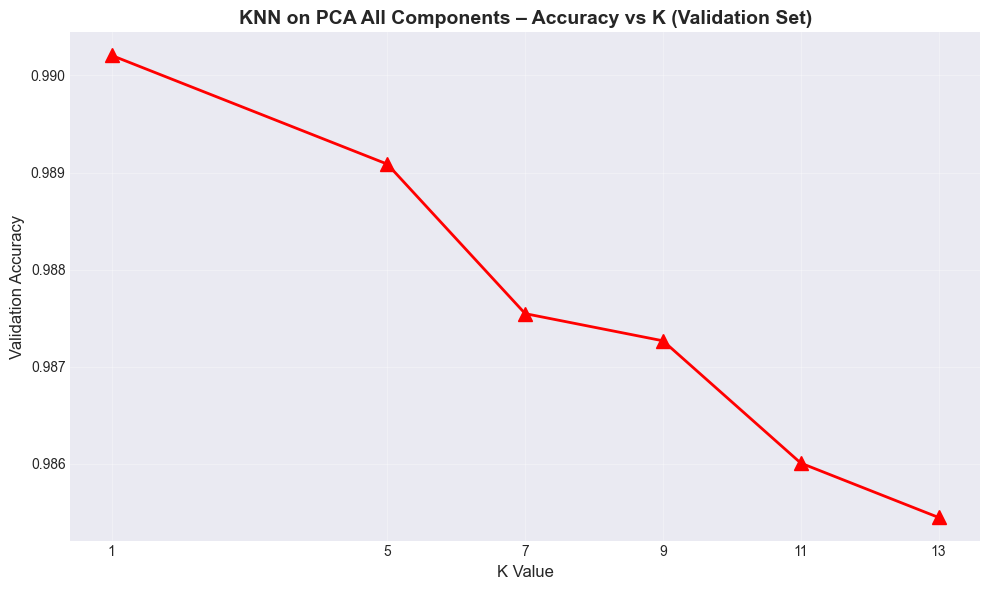

In [64]:
plt.figure(figsize=(10, 6))
plt.plot(val_pa_df['K'], val_pa_df['Accuracy'], 'r^-', linewidth=2, markersize=10)
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.title('KNN on PCA All Components – Accuracy vs K (Validation Set)', 
          fontsize=14, fontweight='bold')
plt.xticks(K_VALUES)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('acc_vs_k_pca_all.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 4: Evaluate Best K on Test Data

In [65]:
# Train KNN with best K on training data
knn_best_pa = KNeighborsClassifier(n_neighbors=int(best_k_pa))
knn_best_pa.fit(X_train_pa, y_train_pa)

# Predict on test set
y_pred_pa = knn_best_pa.predict(X_test_pa)

# Calculate metrics
acc_test_pa = accuracy_score(y_test_pa, y_pred_pa)
prec_micro_test_pa = precision_score(y_test_pa, y_pred_pa, average='micro')
prec_macro_test_pa = precision_score(y_test_pa, y_pred_pa, average='macro')
rec_micro_test_pa = recall_score(y_test_pa, y_pred_pa, average='micro')
rec_macro_test_pa = recall_score(y_test_pa, y_pred_pa, average='macro')
f1_micro_test_pa = f1_score(y_test_pa, y_pred_pa, average='micro')
f1_macro_test_pa = f1_score(y_test_pa, y_pred_pa, average='macro')

# Confusion matrix
cm_pa = confusion_matrix(y_test_pa, y_pred_pa)

print("=" * 70)
print(f"  PART D: KNN ON PCA ALL COMPONENTS – TEST RESULTS (K={int(best_k_pa)})")
print("=" * 70)
print(f"\nAccuracy:         {acc_test_pa:.6f}")
print(f"Precision (Micro): {prec_micro_test_pa:.6f}")
print(f"Precision (Macro): {prec_macro_test_pa:.6f}")
print(f"Recall (Micro):    {rec_micro_test_pa:.6f}")
print(f"Recall (Macro):    {rec_macro_test_pa:.6f}")
print(f"F1-score (Micro):  {f1_micro_test_pa:.6f}")
print(f"F1-score (Macro):  {f1_macro_test_pa:.6f}")
print(f"\nConfusion Matrix:")
print(cm_pa)

# Comparison with previous approaches
print(f"\n{'='*70}")
print("  COMPARISON: Original vs Standardized vs PCA All")
print("=" * 70)
print(f"Original Accuracy:      {acc_test:.6f}")
print(f"Standardized Accuracy:  {acc_test_sc:.6f}")
print(f"PCA All Accuracy:       {acc_test_pa:.6f}")
print(f"\nPCA All vs Original:    {acc_test_pa - acc_test:+.6f}")
print(f"PCA All vs Standardized: {acc_test_pa - acc_test_sc:+.6f}")

  PART D: KNN ON PCA ALL COMPONENTS – TEST RESULTS (K=1)

Accuracy:         0.991885
Precision (Micro): 0.991885
Precision (Macro): 0.992083
Recall (Micro):    0.991885
Recall (Macro):    0.991746
F1-score (Micro):  0.991885
F1-score (Macro):  0.991896

Confusion Matrix:
[[1376    2    2    0    1]
 [   1 1571    3    0    0]
 [   7   12 1373    4    2]
 [   2    1    5 1417    3]
 [   4    9    0    0 1352]]

  COMPARISON: Original vs Standardized vs PCA All
Original Accuracy:      0.991885
Standardized Accuracy:  0.975654
PCA All Accuracy:       0.991885

PCA All vs Original:    +0.000000
PCA All vs Standardized: +0.016231


## Step 5: Plot Confusion Matrix

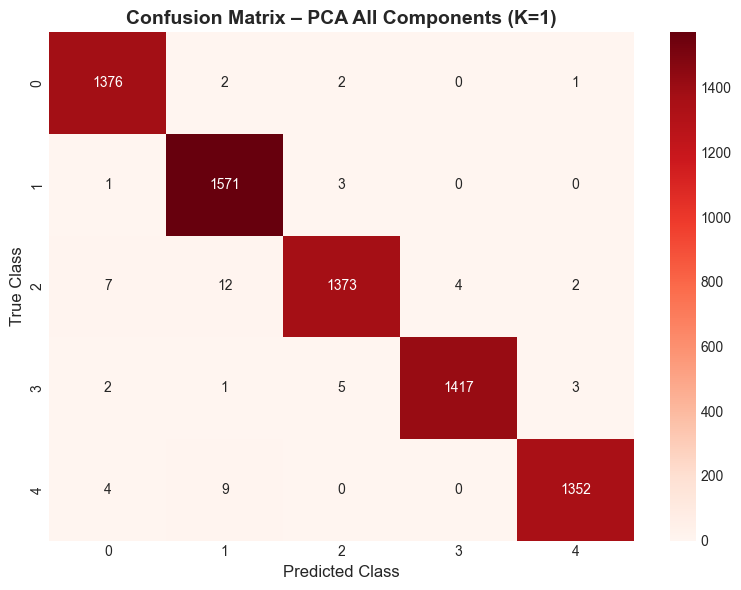

In [66]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_pa, annot=True, fmt='d', cmap='Reds', 
            xticklabels=range(5), yticklabels=range(5))
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.title(f'Confusion Matrix – PCA All Components (K={int(best_k_pa)})', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cm_pca_all.png', dpi=300, bbox_inches='tight')
plt.show()

---
# Part E: KNN on PCA (95% Variance)

## Step 1: Load PCA 95% Data

In [67]:
# Load the PCA 95% variance datasets
train_p95 = pd.read_csv('MNIST_PCA95_Train.csv')
val_p95 = pd.read_csv('MNIST_PCA95_Validation.csv')
test_p95 = pd.read_csv('MNIST_PCA95_Test.csv')

# Separate features and target
X_train_p95 = train_p95.drop('Class', axis=1).values
y_train_p95 = train_p95['Class'].values

X_val_p95 = val_p95.drop('Class', axis=1).values
y_val_p95 = val_p95['Class'].values

X_test_p95 = test_p95.drop('Class', axis=1).values
y_test_p95 = test_p95['Class'].values

print("PCA 95% Variance Data Loaded:")
print(f"  Training:   {X_train_p95.shape}")
print(f"  Validation: {X_val_p95.shape}")
print(f"  Test:       {X_test_p95.shape}")
print(f"\n  Components retained: {X_train_p95.shape[1]}")
print(f"  Original features:   {X_train_orig.shape[1]}")
print(f"  Reduction:           {(1 - X_train_p95.shape[1]/X_train_orig.shape[1])*100:.1f}%")

PCA 95% Variance Data Loaded:
  Training:   (21441, 139)
  Validation: (7147, 139)
  Test:       (7147, 139)

  Components retained: 139
  Original features:   784
  Reduction:           82.3%


## Step 2: KNN with Different K Values on Validation Data

In [68]:
# Store validation results for each K
results_p95 = []

print("Testing KNN on PCA 95% Variance (Validation Set)...\n")
print("K   Accuracy   Prec_Micro  Prec_Macro  Rec_Micro   Rec_Macro   F1_Micro    F1_Macro")
print("=" * 90)

for k in K_VALUES:
    # Train KNN
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_p95, y_train_p95)
    
    # Predict on validation set
    y_pred = knn.predict(X_val_p95)
    
    # Calculate metrics
    acc = accuracy_score(y_val_p95, y_pred)
    prec_micro = precision_score(y_val_p95, y_pred, average='micro')
    prec_macro = precision_score(y_val_p95, y_pred, average='macro')
    rec_micro = recall_score(y_val_p95, y_pred, average='micro')
    rec_macro = recall_score(y_val_p95, y_pred, average='macro')
    f1_micro = f1_score(y_val_p95, y_pred, average='micro')
    f1_macro = f1_score(y_val_p95, y_pred, average='macro')
    
    # Store results
    results_p95.append({
        'K': k,
        'Accuracy': acc,
        'Precision_Micro': prec_micro,
        'Precision_Macro': prec_macro,
        'Recall_Micro': rec_micro,
        'Recall_Macro': rec_macro,
        'F1_Micro': f1_micro,
        'F1_Macro': f1_macro
    })
    
    print(f"{k:2d}  {acc:.6f}  {prec_micro:.6f}  {prec_macro:.6f}  {rec_micro:.6f}  "
          f"{rec_macro:.6f}  {f1_micro:.6f}  {f1_macro:.6f}")

# Convert to DataFrame
val_p95_df = pd.DataFrame(results_p95)

# Find best K based on accuracy
best_k_p95 = val_p95_df.loc[val_p95_df['Accuracy'].idxmax(), 'K']
best_acc_p95 = val_p95_df.loc[val_p95_df['Accuracy'].idxmax(), 'Accuracy']

print("\n" + "=" * 90)
print(f"Best K = {int(best_k_p95)} with Validation Accuracy = {best_acc_p95:.6f}")

Testing KNN on PCA 95% Variance (Validation Set)...

K   Accuracy   Prec_Micro  Prec_Macro  Rec_Micro   Rec_Macro   F1_Micro    F1_Macro
 1  0.991185  0.991185  0.991252  0.991185  0.991099  0.991185  0.991160
 5  0.990625  0.990625  0.990898  0.990625  0.990533  0.990625  0.990686
 7  0.989506  0.989506  0.989891  0.989506  0.989369  0.989506  0.989584
 9  0.988107  0.988107  0.988572  0.988107  0.987970  0.988107  0.988216
11  0.986988  0.986988  0.987607  0.986988  0.986818  0.986988  0.987138
13  0.986708  0.986708  0.987311  0.986708  0.986570  0.986708  0.986874

Best K = 1 with Validation Accuracy = 0.991185


## Step 3: Plot Accuracy vs K

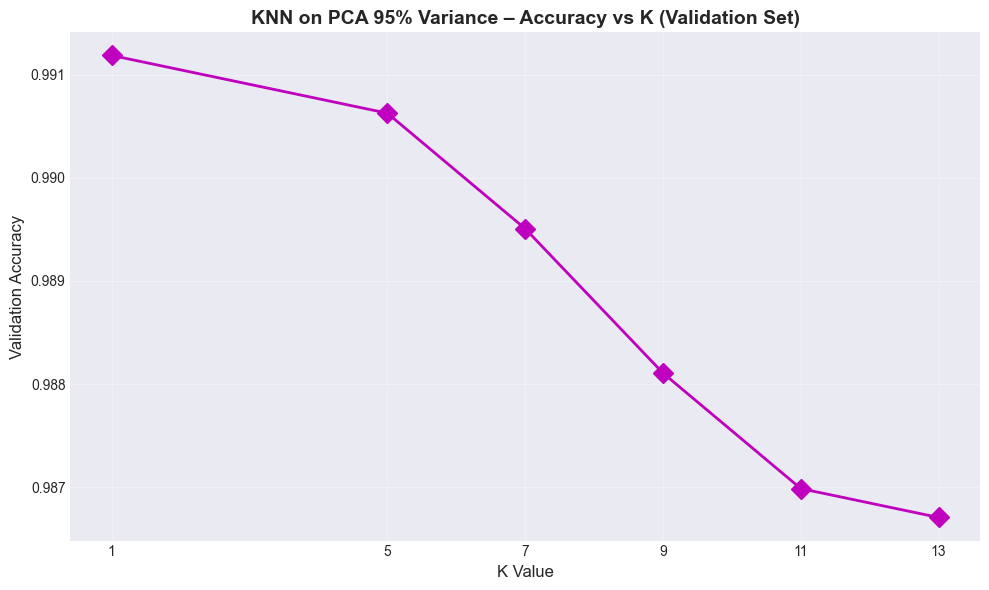

In [69]:
plt.figure(figsize=(10, 6))
plt.plot(val_p95_df['K'], val_p95_df['Accuracy'], 'mD-', linewidth=2, markersize=10)
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.title('KNN on PCA 95% Variance – Accuracy vs K (Validation Set)', 
          fontsize=14, fontweight='bold')
plt.xticks(K_VALUES)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('acc_vs_k_pca95.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 4: Evaluate Best K on Test Data

In [70]:
# Train KNN with best K on training data
knn_best_p95 = KNeighborsClassifier(n_neighbors=int(best_k_p95))
knn_best_p95.fit(X_train_p95, y_train_p95)

# Predict on test set
y_pred_p95 = knn_best_p95.predict(X_test_p95)

# Calculate metrics
acc_test_p95 = accuracy_score(y_test_p95, y_pred_p95)
prec_micro_test_p95 = precision_score(y_test_p95, y_pred_p95, average='micro')
prec_macro_test_p95 = precision_score(y_test_p95, y_pred_p95, average='macro')
rec_micro_test_p95 = recall_score(y_test_p95, y_pred_p95, average='micro')
rec_macro_test_p95 = recall_score(y_test_p95, y_pred_p95, average='macro')
f1_micro_test_p95 = f1_score(y_test_p95, y_pred_p95, average='micro')
f1_macro_test_p95 = f1_score(y_test_p95, y_pred_p95, average='macro')

# Confusion matrix
cm_p95 = confusion_matrix(y_test_p95, y_pred_p95)

print("=" * 70)
print(f"  PART E: KNN ON PCA 95% VARIANCE – TEST RESULTS (K={int(best_k_p95)})")
print("=" * 70)
print(f"\nComponents Retained: {X_train_p95.shape[1]} (out of {X_train_orig.shape[1]})")
print(f"Dimensionality Reduction: {(1 - X_train_p95.shape[1]/X_train_orig.shape[1])*100:.1f}%")
print(f"\nAccuracy:         {acc_test_p95:.6f}")
print(f"Precision (Micro): {prec_micro_test_p95:.6f}")
print(f"Precision (Macro): {prec_macro_test_p95:.6f}")
print(f"Recall (Micro):    {rec_micro_test_p95:.6f}")
print(f"Recall (Macro):    {rec_macro_test_p95:.6f}")
print(f"F1-score (Micro):  {f1_micro_test_p95:.6f}")
print(f"F1-score (Macro):  {f1_macro_test_p95:.6f}")
print(f"\nConfusion Matrix:")
print(cm_p95)

# Comparison with all previous approaches
print(f"\n{'='*70}")
print("  COMPARISON: All Approaches")
print("=" * 70)
print(f"Original Accuracy:      {acc_test:.6f}")
print(f"Standardized Accuracy:  {acc_test_sc:.6f}")
print(f"PCA All Accuracy:       {acc_test_pa:.6f}")
print(f"PCA 95% Accuracy:       {acc_test_p95:.6f}")
print(f"\nPCA 95% vs Original:    {acc_test_p95 - acc_test:+.6f}")
print(f"PCA 95% vs PCA All:     {acc_test_p95 - acc_test_pa:+.6f}")

  PART E: KNN ON PCA 95% VARIANCE – TEST RESULTS (K=1)

Components Retained: 139 (out of 784)
Dimensionality Reduction: 82.3%

Accuracy:         0.992304
Precision (Micro): 0.992304
Precision (Macro): 0.992485
Recall (Micro):    0.992304
Recall (Macro):    0.992146
F1-score (Micro):  0.992304
F1-score (Macro):  0.992302

Confusion Matrix:
[[1374    2    4    0    1]
 [   0 1573    2    0    0]
 [   6   11 1376    4    1]
 [   3    1    6 1416    2]
 [   3    8    1    0 1353]]

  COMPARISON: All Approaches
Original Accuracy:      0.991885
Standardized Accuracy:  0.975654
PCA All Accuracy:       0.991885
PCA 95% Accuracy:       0.992304

PCA 95% vs Original:    +0.000420
PCA 95% vs PCA All:     +0.000420


## Step 5: Plot Confusion Matrix

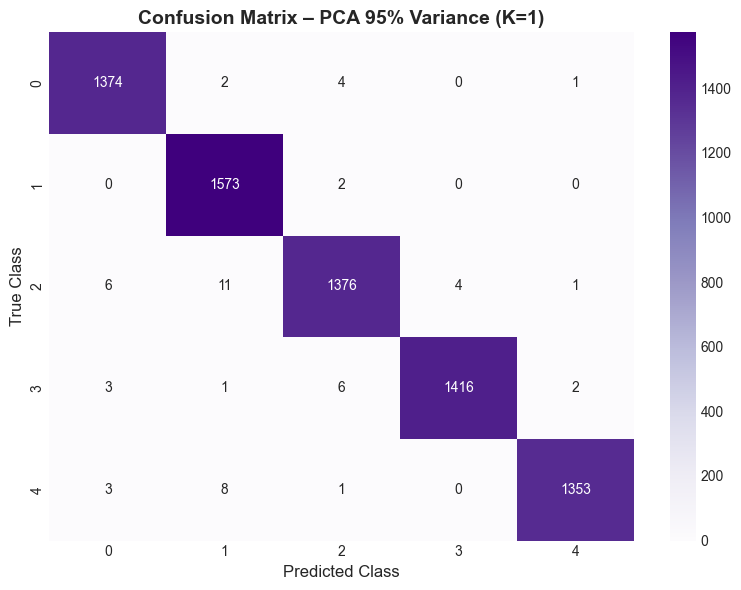

In [71]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_p95, annot=True, fmt='d', cmap='Purples', 
            xticklabels=range(5), yticklabels=range(5))
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.title(f'Confusion Matrix – PCA 95% Variance (K={int(best_k_p95)})', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cm_pca95.png', dpi=300, bbox_inches='tight')
plt.show()

---
# Comparative Analysis

## Combined Accuracy vs K Plot

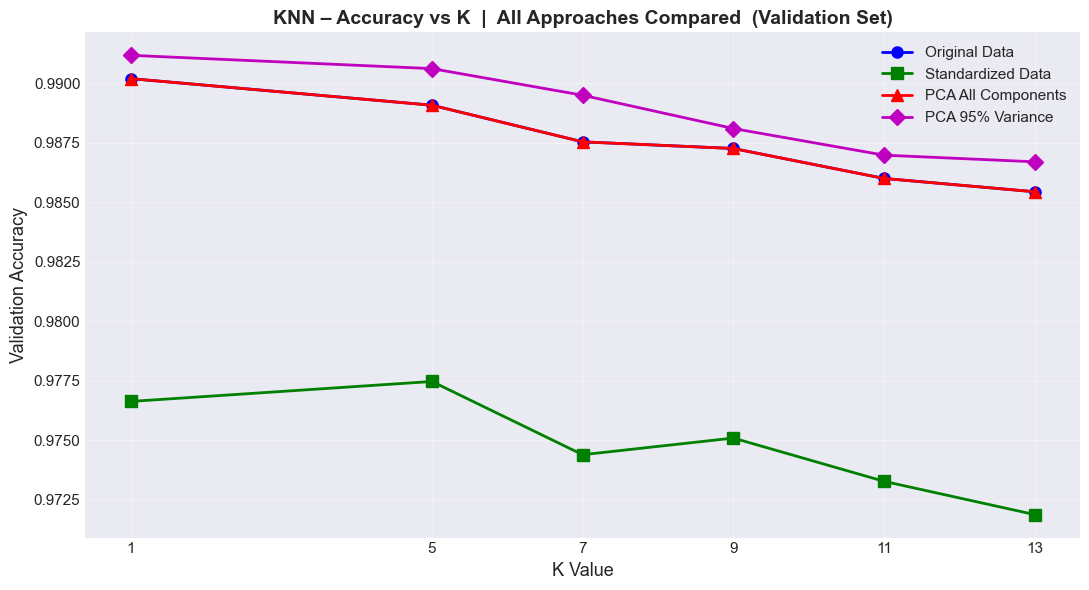

In [72]:
plt.figure(figsize=(11, 6))

plt.plot(val_orig_df['K'],  val_orig_df['Accuracy'],  'bo-', linewidth=2, markersize=8, label='Original Data')
plt.plot(val_sc_df['K'],    val_sc_df['Accuracy'],    'gs-', linewidth=2, markersize=8, label='Standardized Data')
plt.plot(val_pa_df['K'],    val_pa_df['Accuracy'],    'r^-', linewidth=2, markersize=8, label='PCA All Components')
plt.plot(val_p95_df['K'],   val_p95_df['Accuracy'],   'mD-', linewidth=2, markersize=8, label='PCA 95% Variance')

plt.xlabel('K Value', fontsize=13)
plt.ylabel('Validation Accuracy', fontsize=13)
plt.title('KNN – Accuracy vs K  |  All Approaches Compared  (Validation Set)',
          fontsize=14, fontweight='bold')
plt.xticks(K_VALUES, fontsize=11)
plt.yticks(fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11, loc='best')
plt.tight_layout()
plt.savefig('acc_vs_k_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Test Results – Summary Table

In [73]:
# Collect every test prediction set
test_sets = [
    ('Original Data',        y_test_orig, y_pred_orig, best_k_orig, 784),
    ('Standardized Data',    y_test_sc,   y_pred_sc,   best_k_sc,   784),
    ('PCA All Components',   y_test_pa,   y_pred_pa,   best_k_pa,   X_train_pa.shape[1]),
    ('PCA 95% Variance',     y_test_p95,  y_pred_p95,  best_k_p95,  X_train_p95.shape[1])
]

rows = []
for label, y_t, y_p, bk, n_feat in test_sets:
    rows.append({
        'Approach'        : label,
        'Features'        : n_feat,
        'Best K'          : bk,
        'Accuracy'        : accuracy_score(y_t, y_p),
        'Precision_Micro' : precision_score(y_t, y_p, average='micro'),
        'Precision_Macro' : precision_score(y_t, y_p, average='macro'),
        'Recall_Micro'    : recall_score(y_t, y_p,    average='micro'),
        'Recall_Macro'    : recall_score(y_t, y_p,    average='macro'),
        'F1_Micro'        : f1_score(y_t, y_p,        average='micro'),
        'F1_Macro'        : f1_score(y_t, y_p,        average='macro')
    })

summary_df = pd.DataFrame(rows)

print("=" * 110)
print("  FINAL TEST SET – COMPARISON TABLE")
print("=" * 110)
print(summary_df.round(4).to_string(index=False))
print("=" * 110)

# Save to CSV
summary_df.to_csv('test_results_comparison.csv', index=False)
print("\nSaved → test_results_comparison.csv")

  FINAL TEST SET – COMPARISON TABLE
          Approach  Features  Best K  Accuracy  Precision_Micro  Precision_Macro  Recall_Micro  Recall_Macro  F1_Micro  F1_Macro
     Original Data       784       1    0.9919           0.9919           0.9921        0.9919        0.9917    0.9919    0.9919
 Standardized Data       784       5    0.9757           0.9757           0.9758        0.9757        0.9754    0.9757    0.9756
PCA All Components       784       1    0.9919           0.9919           0.9921        0.9919        0.9917    0.9919    0.9919
  PCA 95% Variance       139       1    0.9923           0.9923           0.9925        0.9923        0.9921    0.9923    0.9923

Saved → test_results_comparison.csv


## Key Observations and Analysis

In [74]:
print("=" * 65)
print("  KEY OBSERVATIONS")
print("=" * 65)

# ---- 1. Best overall approach ----
best_row = summary_df.loc[summary_df['Accuracy'].idxmax()]
print(f"\n1. Best Overall Approach")
print(f"   Approach  : {best_row['Approach']}")
print(f"   Accuracy  : {best_row['Accuracy']:.4f}")
print(f"   Best K    : {int(best_row['Best K'])}")
print(f"   Features  : {int(best_row['Features'])}")

# ---- 2. Impact of standardization ----
acc_orig = summary_df.loc[summary_df['Approach'] == 'Original Data',      'Accuracy'].values[0]
acc_sc   = summary_df.loc[summary_df['Approach'] == 'Standardized Data',  'Accuracy'].values[0]
print(f"\n2. Impact of Standardization")
print(f"   Original accuracy     : {acc_orig:.4f}")
print(f"   Standardized accuracy : {acc_sc:.4f}")
print(f"   Change                : {acc_sc - acc_orig:+.4f}  "
      f"({'IMPROVED' if acc_sc >= acc_orig else 'DECREASED'})")

# ---- 3. PCA 95% – dimensionality reduction ----
n_orig  = 784
n_p95   = int(summary_df.loc[summary_df['Approach'] == 'PCA 95% Variance', 'Features'].values[0])
acc_p95 = summary_df.loc[summary_df['Approach'] == 'PCA 95% Variance',     'Accuracy'].values[0]
print(f"\n3. PCA 95% – Dimensionality Reduction")
print(f"   Original features : {n_orig}")
print(f"   Retained features : {n_p95}")
print(f"   Reduction         : {(1 - n_p95/n_orig)*100:.1f} %")
print(f"   Accuracy change   : {acc_p95 - acc_orig:+.4f}  vs Original")

# ---- 4. PCA All vs PCA 95% ----
acc_pa  = summary_df.loc[summary_df['Approach'] == 'PCA All Components',  'Accuracy'].values[0]
print(f"\n4. PCA All Components  vs  PCA 95% Variance")
print(f"   PCA All accuracy  : {acc_pa:.4f}  ({n_orig} components)")
print(f"   PCA 95% accuracy  : {acc_p95:.4f}  ({n_p95} components)")
print(f"   Difference        : {acc_p95 - acc_pa:+.4f}")

print("\n" + "=" * 65)

  KEY OBSERVATIONS

1. Best Overall Approach
   Approach  : PCA 95% Variance
   Accuracy  : 0.9923
   Best K    : 1
   Features  : 139

2. Impact of Standardization
   Original accuracy     : 0.9919
   Standardized accuracy : 0.9757
   Change                : -0.0162  (DECREASED)

3. PCA 95% – Dimensionality Reduction
   Original features : 784
   Retained features : 139
   Reduction         : 82.3 %
   Accuracy change   : +0.0004  vs Original

4. PCA All Components  vs  PCA 95% Variance
   PCA All accuracy  : 0.9919  (784 components)
   PCA 95% accuracy  : 0.9923  (139 components)
   Difference        : +0.0004

